# Armina Forecast

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

# 1. Load data
df = pd.read_csv("../datasets/delivery_clean_data.csv")
df["date"] = pd.to_datetime(df["date"])
df.set_index("date", inplace=True)

# 2. Assign daily frequency (Crucial for ARIMA to handle dates smoothly)
df = df.asfreq("D")

print("Data ready for ARIMA modeling")

Data ready for ARIMA modeling


In [3]:
# 1. Initialize the ARIMA model
# We train it on the 'deliveries' column using the order (p,d,q) = (5,1,0)
model = ARIMA(df["deliveries"], order=(5, 1, 0))
result = model.fit()

# Print the summary statistics of the model
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             deliveries   No. Observations:                  500
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -2136.792
Date:                Fri, 26 Jun 2026   AIC                           4285.584
Time:                        14:44:41   BIC                           4310.860
Sample:                    01-01-2025   HQIC                          4295.503
                         - 05-15-2026                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3202      0.036     -8.821      0.000      -0.391      -0.249
ar.L2         -0.5920      0.032    -18.701      0.000      -0.654      -0.530
ar.L3         -0.4348      0.043    -10.099      0.000      -0.519      -0.350
ar.L4         -0.3356      0.034     -9.950      0.000      -0.402      -0.269
ar.L5         -0.6041      0.037    -16.342      0.000      -0.677      -0.532
sigma2       305.1001     19.977     15.273      0.000     265.946     344.254
===================================================================================
Ljung-Box (L1) (Q):                  73.67   Jarque-Bera (JB):                 0.56
Prob(Q):                              0.00   Prob(JB):                         0.75
Heteroskedasticity (H):               1.18   Skew:                             0.07
Prob(H) (two-sided):                  0.29   Kurtosis:                         2.92
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

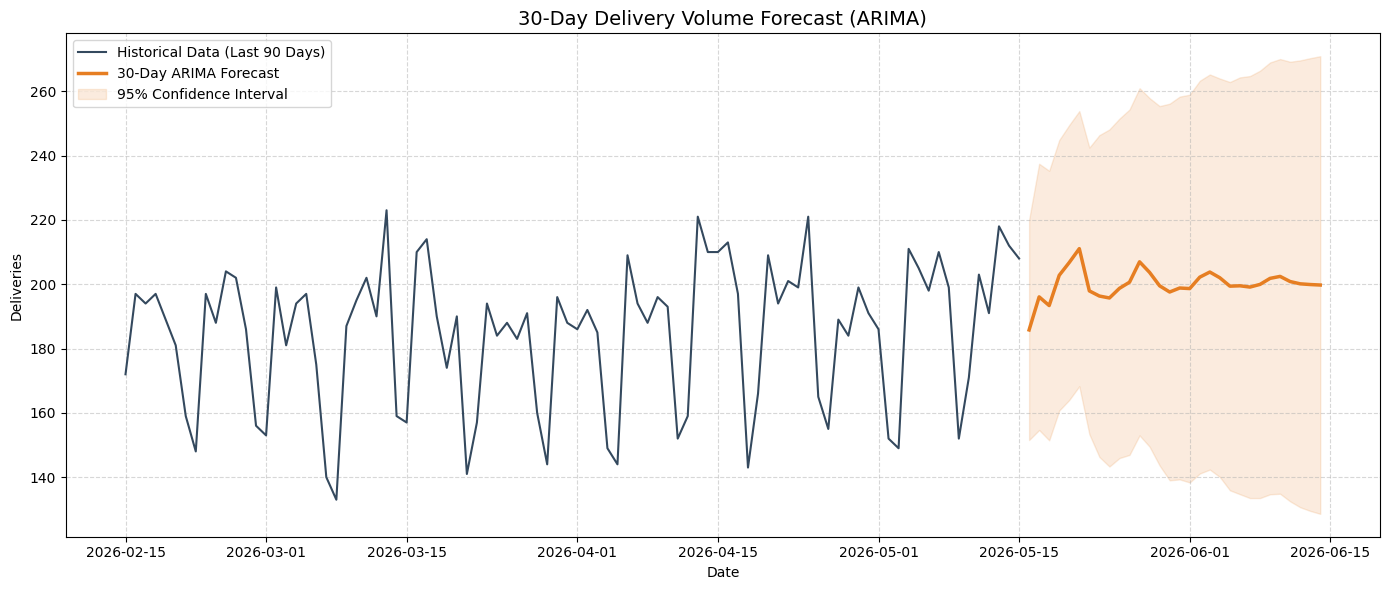

In [4]:
# 1. Forecast 30 steps ahead
forecast_steps = 30
forecast_res = result.get_forecast(steps=forecast_steps)

# Extract predicted values and confidence intervals
forecast_values = forecast_res.predicted_mean
confidence_intervals = forecast_res.conf_int()

# 2. Create matching future dates for plotting
future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1), periods=forecast_steps, freq="D"
)

# 3. Visualization
plt.figure(figsize=(14, 6))

# Plot historical data (Last 90 days for visual clarity)
plt.plot(df.index[-90:], df["deliveries"][-90:], label="Historical Data (Last 90 Days)", color="#34495e")

# Plot ARIMA Forecast
plt.plot(future_dates, forecast_values, label="30-Day ARIMA Forecast", color="#e67e22", linewidth=2.5)

# Plot Confidence Intervals (Uncertainty)
plt.fill_between(
    future_dates,
    confidence_intervals.iloc[:, 0],
    confidence_intervals.iloc[:, 1],
    color="#e67e22",
    alpha=0.15,
    label="95% Confidence Interval"
)

plt.title("30-Day Delivery Volume Forecast (ARIMA)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Deliveries")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()